# IPL Data Analysis Project
### End-to-End Exploratory Data Analysis of Indian Premier League (2008-2017)

**Datasets used:**
- `matches.csv` — 636 matches with season, teams, toss, result, venue, player of match, etc.
- `deliveries.csv` — 179,078 ball-by-ball records with batsman, bowler, runs, dismissals.

**Objective:** Analyze team performance, player performance, toss impact, venue trends, and scoring patterns across 10 IPL seasons to generate business-style insights.

---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
matches.head()

Matches shape: (636, 18)
Deliveries shape: (179078, 21)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


## 2. Data Cleaning

In [2]:
# Fix inconsistent team names across seasons
team_fix = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_fix)
for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(team_fix)

# Handle missing values
matches['city'] = matches['city'].fillna('Unknown')
matches['winner'] = matches['winner'].fillna('No Result')
matches['date'] = pd.to_datetime(matches['date'], dayfirst=True, errors='coerce')

print("Missing winners (no-result matches):", (matches['winner']=='No Result').sum())
matches.isnull().sum()

Missing winners (no-result matches): 3


id                   0
season               0
city                 0
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               0
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

## 3. Matches Played Per Season

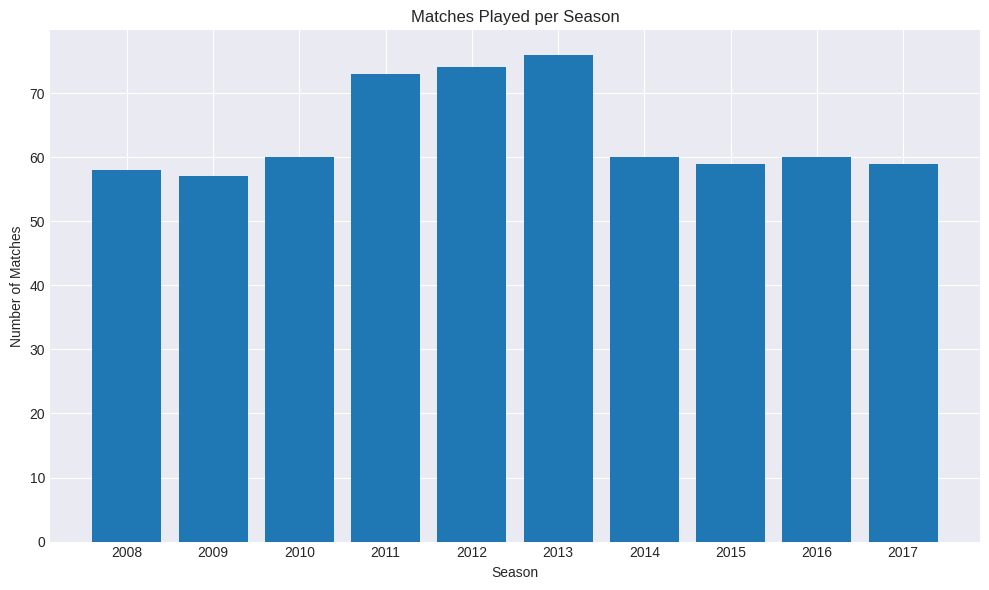

,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [3]:
season_counts = matches.groupby('season').size().reset_index(name='matches')

plt.figure()
plt.bar(season_counts['season'].astype(str), season_counts['matches'], color='#1f77b4')
plt.title('Matches Played per Season')
plt.xlabel('Season'); plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

season_counts

## 4. Most Successful Teams (Total Wins)

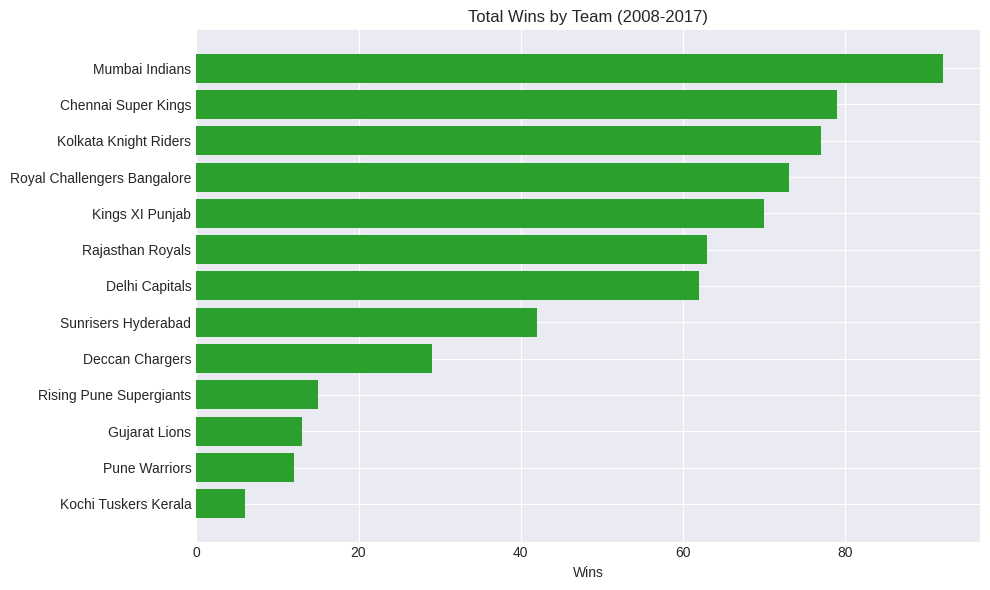

,team,wins
0,Mumbai Indians,92
1,Chennai Super Kings,79
2,Kolkata Knight Riders,77
3,Royal Challengers Bangalore,73
4,Kings XI Punjab,70
5,Rajasthan Royals,63
6,Delhi Capitals,62
7,Sunrisers Hyderabad,42
8,Deccan Chargers,29
9,Rising Pune Supergiants,15


In [4]:
team_wins = matches[matches['winner'] != 'No Result']['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']

plt.figure()
plt.barh(team_wins['team'][::-1], team_wins['wins'][::-1], color='#2ca02c')
plt.title('Total Wins by Team (2008-2017)')
plt.xlabel('Wins')
plt.tight_layout()
plt.show()

team_wins.head(10)

## 5. Does Winning the Toss Help Win the Match?

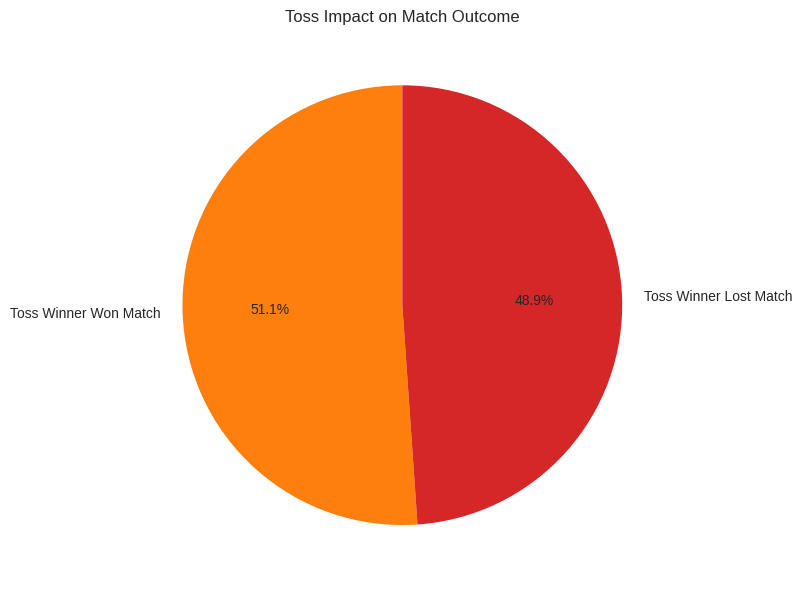

toss_win_match_win
True     51.1
False    48.9
Name: proportion, dtype: float64


In [5]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_win_match_win'].value_counts(normalize=True).mul(100).round(1)

plt.figure()
plt.pie(toss_impact.values, labels=['Toss Winner Won Match', 'Toss Winner Lost Match'],
        autopct='%1.1f%%', colors=['#ff7f0e', '#d62728'], startangle=90)
plt.title('Toss Impact on Match Outcome')
plt.tight_layout()
plt.show()

print(toss_impact)

## 6. Toss Decision Preference — Bat vs Field

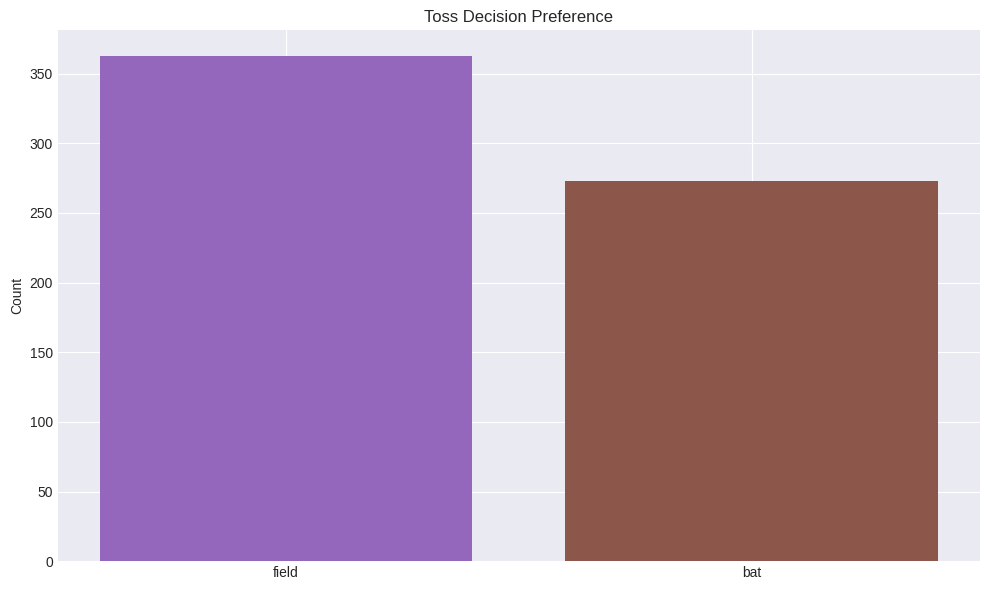

toss_decision
field    363
bat      273
Name: count, dtype: int64

In [6]:
toss_dec = matches['toss_decision'].value_counts()

plt.figure()
plt.bar(toss_dec.index, toss_dec.values, color=['#9467bd', '#8c564b'])
plt.title('Toss Decision Preference')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

toss_dec

## 7. Top 10 Run Scorers

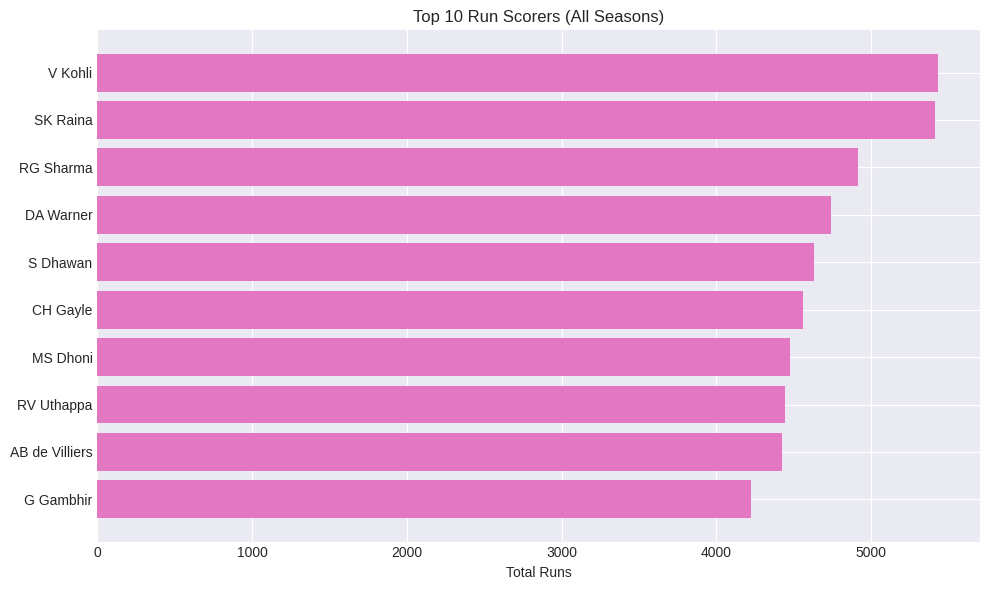

,batsman,total_runs
0,V Kohli,5434
1,SK Raina,5415
2,RG Sharma,4914
3,DA Warner,4741
4,S Dhawan,4632
5,CH Gayle,4560
6,MS Dhoni,4477
7,RV Uthappa,4446
8,AB de Villiers,4428
9,G Gambhir,4223


In [7]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10).reset_index()
top_batsmen.columns = ['batsman', 'total_runs']

plt.figure()
plt.barh(top_batsmen['batsman'][::-1], top_batsmen['total_runs'][::-1], color='#e377c2')
plt.title('Top 10 Run Scorers (All Seasons)')
plt.xlabel('Total Runs')
plt.tight_layout()
plt.show()

top_batsmen

## 8. Top 10 Wicket Takers

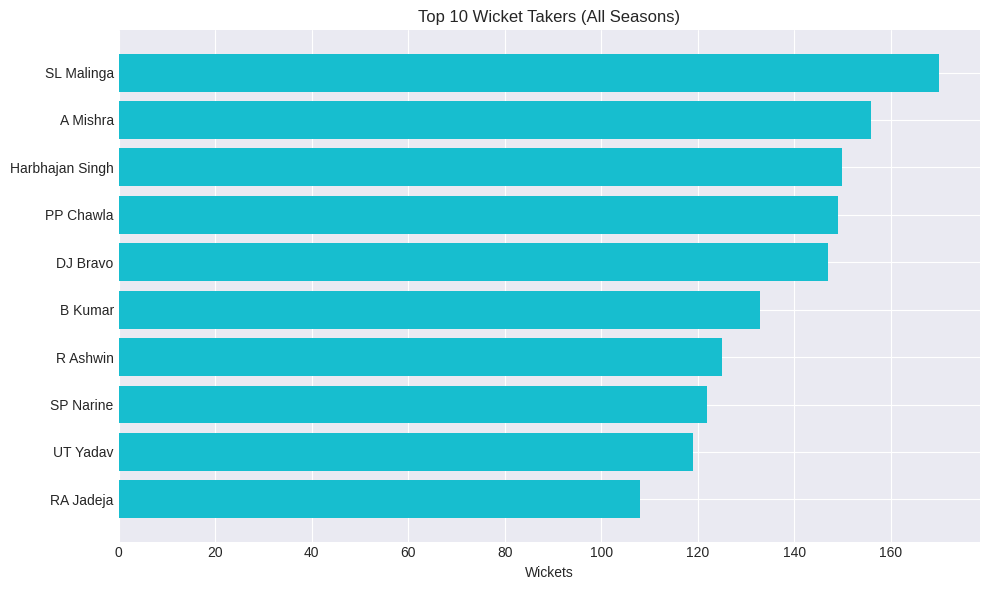

,bowler,wickets
0,SL Malinga,170
1,A Mishra,156
2,Harbhajan Singh,150
3,PP Chawla,149
4,DJ Bravo,147
5,B Kumar,133
6,R Ashwin,125
7,SP Narine,122
8,UT Yadav,119
9,RA Jadeja,108


In [8]:
dismissals_valid = deliveries[~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = dismissals_valid.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10).reset_index()
top_bowlers.columns = ['bowler', 'wickets']

plt.figure()
plt.barh(top_bowlers['bowler'][::-1], top_bowlers['wickets'][::-1], color='#17becf')
plt.title('Top 10 Wicket Takers (All Seasons)')
plt.xlabel('Wickets')
plt.tight_layout()
plt.show()

top_bowlers

## 9. Most 'Player of the Match' Awards

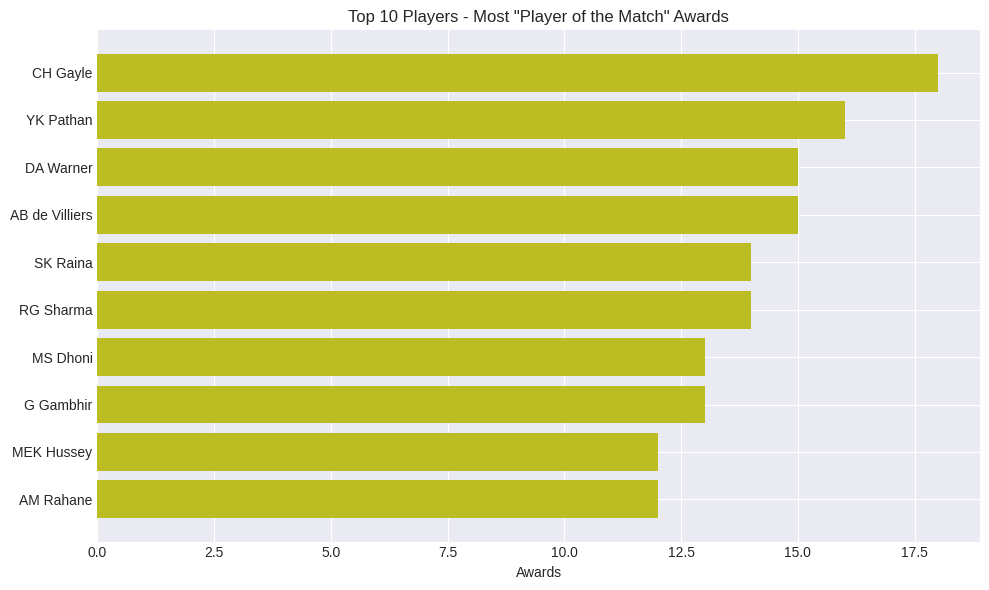

,player,awards
0,CH Gayle,18
1,YK Pathan,16
2,DA Warner,15
3,AB de Villiers,15
4,SK Raina,14
5,RG Sharma,14
6,MS Dhoni,13
7,G Gambhir,13
8,MEK Hussey,12
9,AM Rahane,12


In [9]:
pom = matches['player_of_match'].value_counts().head(10).reset_index()
pom.columns = ['player', 'awards']

plt.figure()
plt.barh(pom['player'][::-1], pom['awards'][::-1], color='#bcbd22')
plt.title('Top 10 Players - Most "Player of the Match" Awards')
plt.xlabel('Awards')
plt.tight_layout()
plt.show()

pom

## 10. Highest Innings Totals

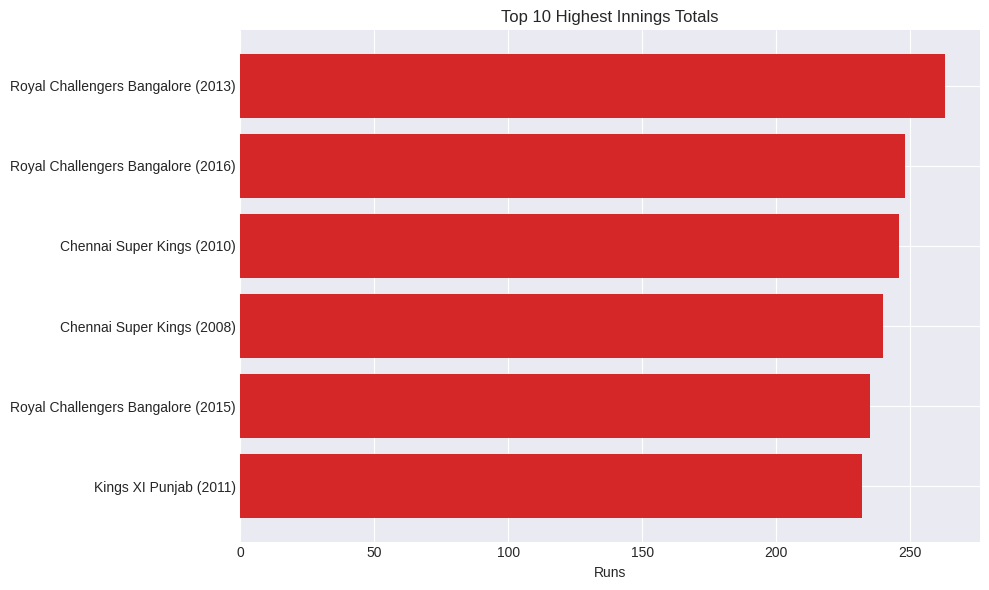

,label,total_runs
0,Royal Challengers Bangalore (2013),263
1,Royal Challengers Bangalore (2016),248
2,Chennai Super Kings (2010),246
3,Chennai Super Kings (2008),240
4,Royal Challengers Bangalore (2015),235
5,Kings XI Punjab (2011),232


In [10]:
inn_totals = deliveries.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()
top_totals = inn_totals.sort_values('total_runs', ascending=False).head(10)
top_totals = top_totals.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
top_totals['label'] = top_totals['batting_team'] + ' (' + top_totals['season'].astype(str) + ')'

plt.figure()
plt.barh(top_totals['label'][::-1], top_totals['total_runs'][::-1], color='#d62728')
plt.title('Top 10 Highest Innings Totals')
plt.xlabel('Runs')
plt.tight_layout()
plt.show()

top_totals[['label', 'total_runs']]

## 11. Top 10 Venues by Matches Hosted

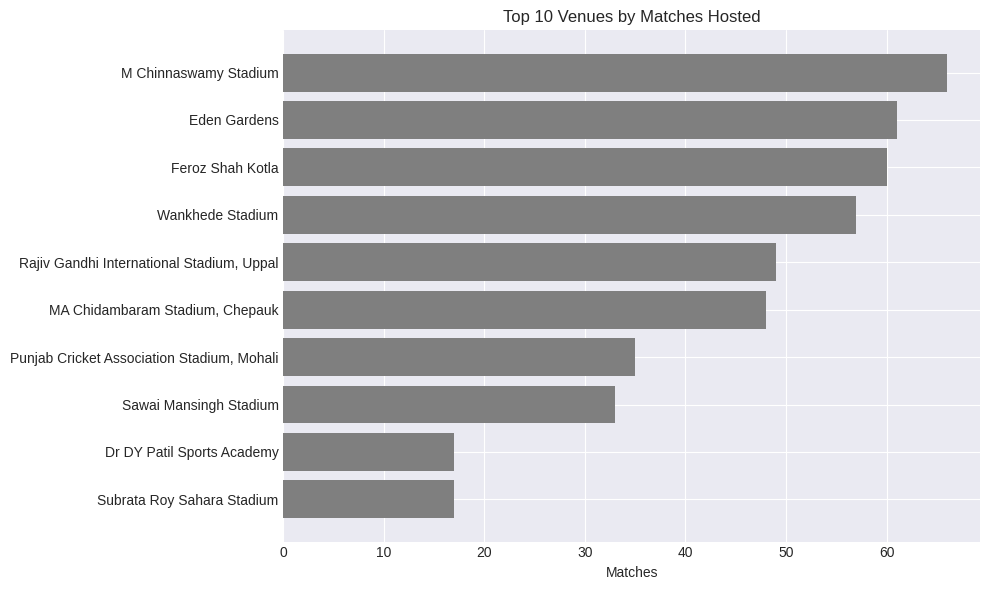

,venue,matches
0,M Chinnaswamy Stadium,66
1,Eden Gardens,61
2,Feroz Shah Kotla,60
3,Wankhede Stadium,57
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,"Punjab Cricket Association Stadium, Mohali",35
7,Sawai Mansingh Stadium,33
8,Dr DY Patil Sports Academy,17
9,Subrata Roy Sahara Stadium,17


In [11]:
venue_counts = matches['venue'].value_counts().head(10).reset_index()
venue_counts.columns = ['venue', 'matches']

plt.figure()
plt.barh(venue_counts['venue'][::-1], venue_counts['matches'][::-1], color='#7f7f7f')
plt.title('Top 10 Venues by Matches Hosted')
plt.xlabel('Matches')
plt.tight_layout()
plt.show()

venue_counts

## 12. Win Margin Distribution

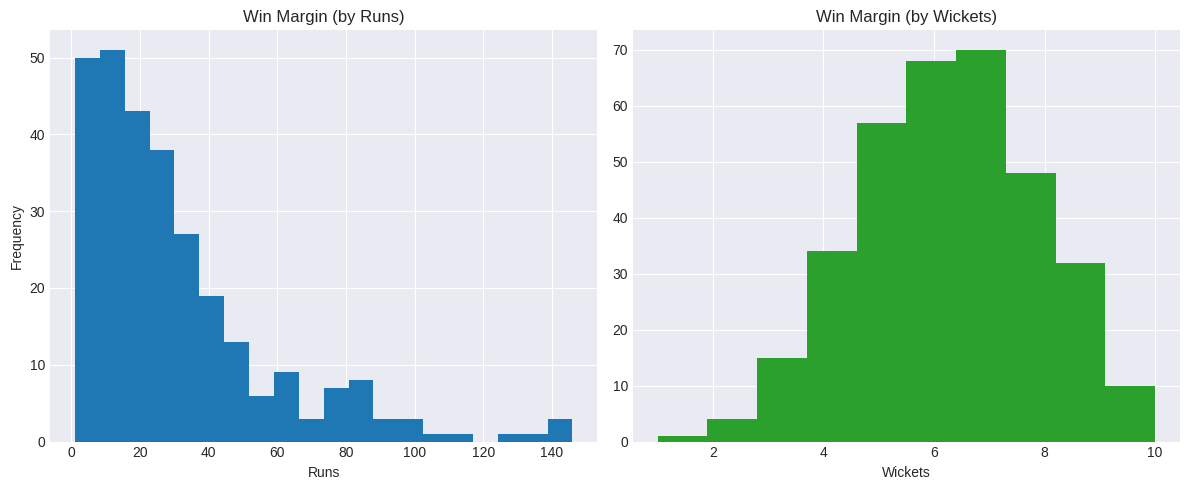

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(matches[matches['win_by_runs'] > 0]['win_by_runs'], bins=20, color='#1f77b4')
axes[0].set_title('Win Margin (by Runs)')
axes[0].set_xlabel('Runs'); axes[0].set_ylabel('Frequency')
axes[1].hist(matches[matches['win_by_wickets'] > 0]['win_by_wickets'], bins=10, color='#2ca02c')
axes[1].set_title('Win Margin (by Wickets)')
axes[1].set_xlabel('Wickets')
plt.tight_layout()
plt.show()

## 13. Season-wise Wins Trend — Top 6 Teams

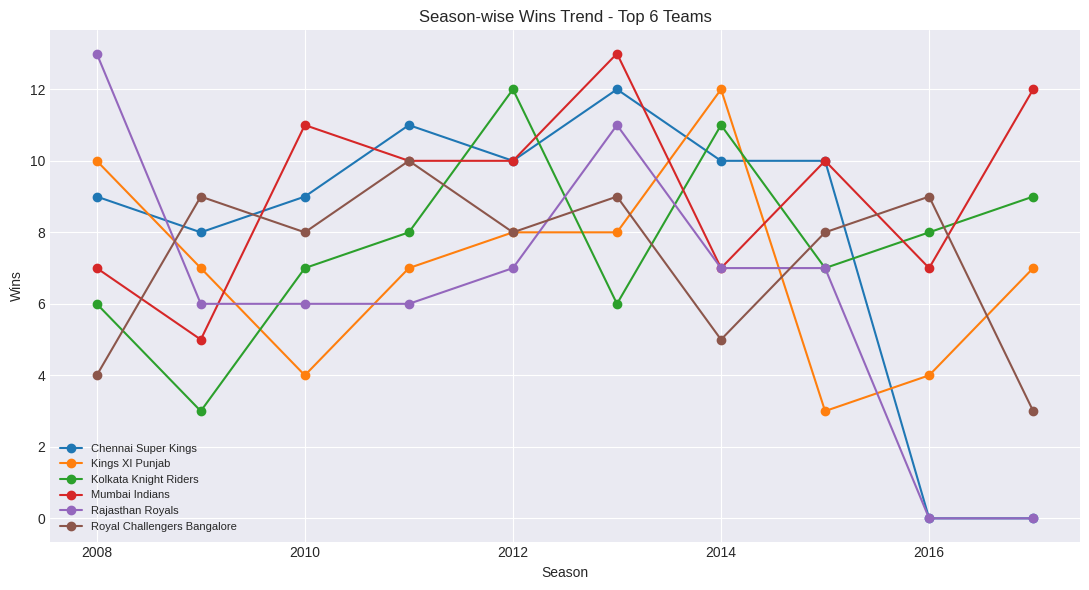

In [13]:
season_wins = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
top6 = team_wins['team'].head(6).tolist()
pivot = season_wins[season_wins['winner'].isin(top6)].pivot(index='season', columns='winner', values='wins').fillna(0)

plt.figure(figsize=(11, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col)
plt.title('Season-wise Wins Trend - Top 6 Teams')
plt.xlabel('Season'); plt.ylabel('Wins'); plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 14. Scoring Pattern by Match Phase (Powerplay / Middle / Death)

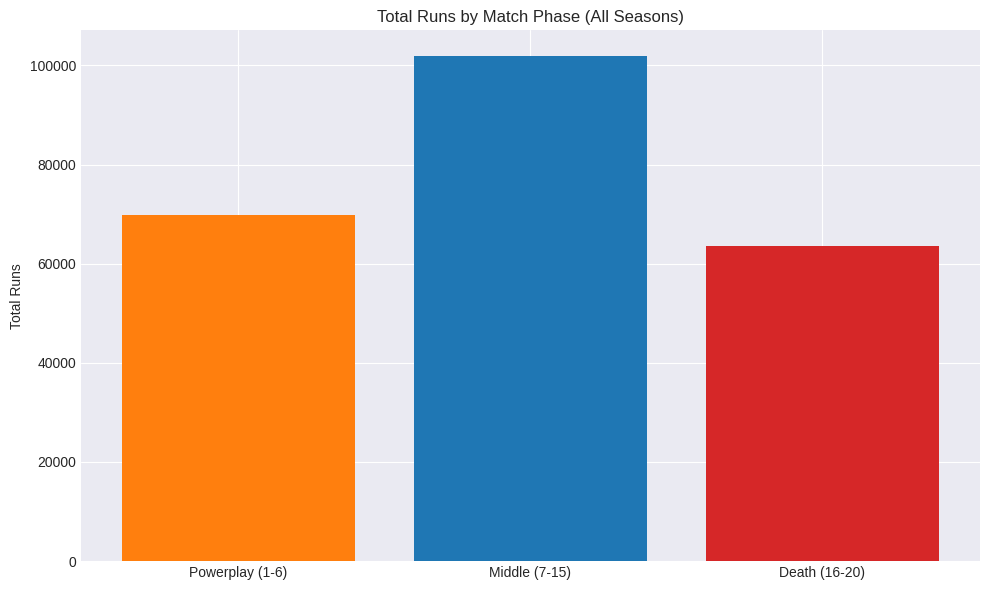

phase
Powerplay (1-6)     69831
Middle (7-15)      101981
Death (16-20)       63478
Name: total_runs, dtype: int64

In [14]:
def phase(o):
    if o <= 6: return 'Powerplay (1-6)'
    elif o <= 15: return 'Middle (7-15)'
    else: return 'Death (16-20)'

deliveries['phase'] = deliveries['over'].apply(phase)
phase_runs = deliveries.groupby('phase')['total_runs'].sum().reindex(['Powerplay (1-6)', 'Middle (7-15)', 'Death (16-20)'])

plt.figure()
plt.bar(phase_runs.index, phase_runs.values, color=['#ff7f0e', '#1f77b4', '#d62728'])
plt.title('Total Runs by Match Phase (All Seasons)')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.show()

phase_runs

## 15. Key Insights Summary

1. **Mumbai Indians** are the most successful franchise with the most total wins across 2008-2017, followed closely by Chennai Super Kings.
2. **Toss winners have only a slight edge** — they win the match ~51% of the time, meaning toss is close to a coin-flip in terms of actual advantage.
3. Teams **prefer fielding first** after winning the toss in the majority of matches, reflecting the "chasing is easier under lights" trend.
4. **Virat Kohli** is the highest run-scorer across all seasons, and **SL Malinga** leads in total wickets taken.
5. **Death overs (16-20)** produce disproportionately higher scoring than powerplay/middle overs, confirming the "slog overs" strategy dominance.
6. **Eden Gardens and M. Chinnaswamy Stadium** are among the most-used venues, hosting the highest number of matches.
7. Season-wise trends show **Mumbai Indians and Chennai Super Kings maintaining consistent top-6 form** across nearly every season, unlike other franchises with fluctuating performance.

---
### Next Steps
- Full interactive dashboard available in the accompanying **Power BI** file.
- Detailed write-up available in the **PDF insights report**.
